# Kaggle Housing Price Prediction
Notebook for the *Housing Prices Competition for Kaggle Learn Users*

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

from pandas.api.types import CategoricalDtype

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression


from xgboost import XGBRegressor

## Explore Preprocessing for Test Data

In [2]:
# Load the Kaggle dataset
path_train = './input/train.csv.gz'
train = pd.read_csv(path_train, compression='gzip', index_col='Id')

print(f'Shape of train_full dataset: {train.shape}')

Shape of train_full dataset: (1460, 80)


### Address Missing Data

In [3]:
# look for columns with a lot of missing data
missing_count = train.isnull().sum().sort_values(ascending=False)
missing_pct   = ((train.isnull().sum() / train.isnull().count()).sort_values(ascending=False) * 100).astype(int).astype(str) + '%'
missing_data  = pd.concat([missing_count, missing_pct], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1453,99%
MiscFeature,1406,96%
Alley,1369,93%
Fence,1179,80%
MasVnrType,872,59%
FireplaceQu,690,47%
LotFrontage,259,17%
GarageQual,81,5%
GarageType,81,5%
GarageFinish,81,5%


In [4]:
# some columns here are nan for no feature so we can encode that instead of keeping values nan
train['PoolQC']        = train['PoolQC'].fillna('NA')
train['MiscFeature']   = train['MiscFeature'].fillna('NA')
train['Alley']         = train['Alley'].fillna('NA')
train['Fence']         = train['Fence'].fillna('NA')
train['MasVnrType']    = train['MasVnrType'].fillna('NA')
train['FireplaceQu']   = train['FireplaceQu'].fillna('NA')
train['GarageQual']    = train['GarageQual'].fillna('NA')
train['GarageFinish']  = train['GarageFinish'].fillna('NA')
train['GarageType']    = train['GarageType'].fillna('NA')
train['GarageCond']    = train['GarageCond'].fillna('NA')
train['BsmtFinType2']  = train['BsmtFinType2'].fillna('NA')
train['BsmtExposure']  = train['BsmtExposure'].fillna('NA')
train['BsmtCond']      = train['BsmtCond'].fillna('NA')
train['BsmtQual']      = train['BsmtQual'].fillna('NA')
train['BsmtFinType1']  = train['BsmtFinType1'].fillna('NA')

# no definition for nan in Electrical, only 1 missing so impute with mode
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

# check which columns are remaining
print(f'Remaining NaN values:\n{train.isnull().sum().sort_values(ascending=False).head()}')

Remaining NaN values:
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
MSSubClass       0
Street           0
dtype: int64


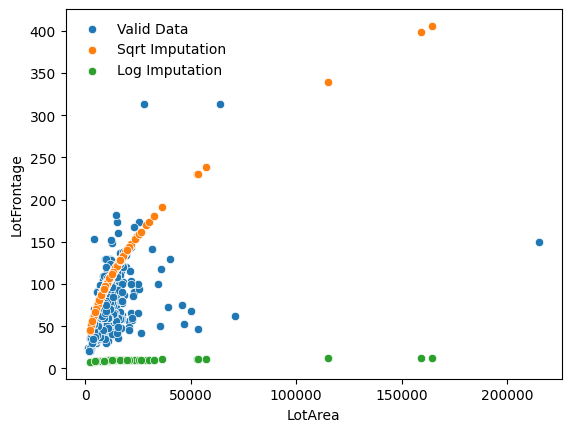

In [5]:
# figure out what to do with LotFrontage

# guess how to impute nans by filling with a transformation of LotArea
train['RootArea'] = np.sqrt(train['LotArea'])
train['LogArea']  = np.log(train['LotArea'])

fig, ax = plt.subplots()

sns.scatterplot(data=train, x='LotArea', y='LotFrontage', label='Valid Data')
sns.scatterplot(data=train[train['LotFrontage'].isna()], x='LotArea', y='RootArea', label='Sqrt Imputation')
sns.scatterplot(data=train[train['LotFrontage'].isna()], x='LotArea', y='LogArea', label='Log Imputation')

ax.legend(frameon=False)
plt.show()

# filling missing LotFrontage with the root of LotArea seems to agree
# reasonably well with the bulk of the data so it's probalby good
# enough for now
train['LotFrontage'] = train['LotFrontage'].fillna(train['RootArea'])

train = train.drop(columns=['RootArea', 'LogArea'])

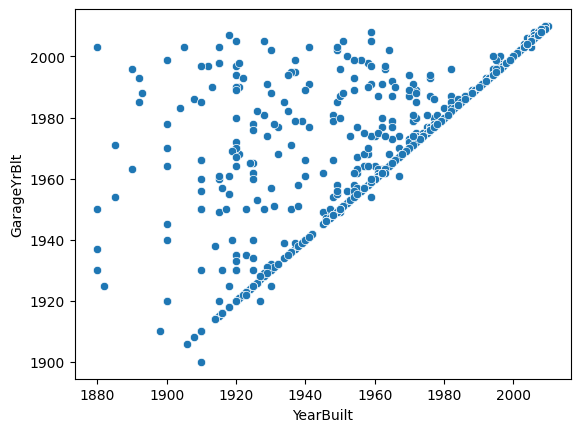

In [6]:
# figure out what to do wtih GarageYrBlt

sns.scatterplot(train, x='YearBuilt', y='GarageYrBlt')
plt.show()

# nan here probably means that there is no garage so just make a new
# HasGarage to flag this and impute missing values with YearBuilt
# so missing values are roughly in line with rest of the data
train['HasGarage']   = (~train['GarageYrBlt'].isna()).astype(int)
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(train['YearBuilt'])

# looks like some data has the garage built before the house?
# just set these values to YearBuilt
train.loc[train['GarageYrBlt'] < train['YearBuilt'], 'GarageYrBlt'] = train['YearBuilt']

      MasVnrArea MasVnrType
Id                         
235          NaN         NA
530          NaN         NA
651          NaN         NA
937          NaN         NA
974          NaN         NA
978          NaN         NA
1244         NaN         NA
1279         NaN         NA


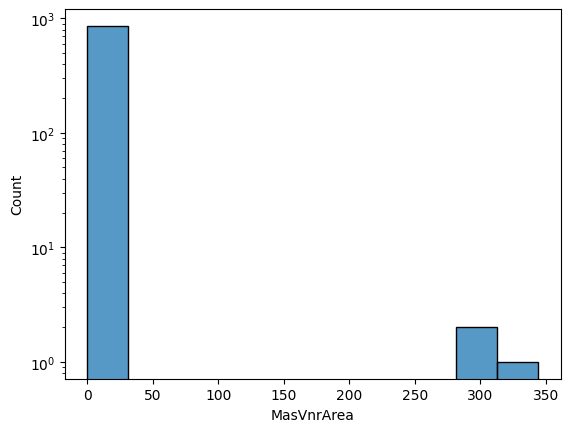

In [7]:
# figure out what to do with MasVnrArea

# MasVnrArea is only nan when MasVnrType is NA
print(train[train['MasVnrArea'].isna()][['MasVnrArea', 'MasVnrType']])

# most MasVnrArea values are 0 when MasVnrType is NA so just impute with 0
sns.histplot(train[train['MasVnrType'] == 'NA']['MasVnrArea'])
plt.yscale('log')
plt.show()

train['MasVnrArea'] = train['MasVnrArea'].fillna(0)

In [8]:
# confirm there is no more missing data
print(f'Remaining NaN values:\n{train.isnull().sum().sort_values(ascending=False).head()}')

Remaining NaN values:
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
dtype: int64


In [9]:
def clean(df):
    '''
    Applies preliminary data cleaning to the provided
    dataframe based on the cells above
    '''
    # set missing GarageYrBlt values to YearBuilt
    df.loc[df['GarageYrBlt'] < df['YearBuilt'], 'GarageYrBlt'] = df['YearBuilt']

    return df


def impute(df, impute_stats=None):
    '''
    Impute the columns in the provided dataframe
    based on the results of the cells above

    impute_stats is a dict that specifies values to
    use for imputing that need to be collected from
    training data 
    '''
    # first handle special cases

    # estimate missing LotFrontage by the root of LotArea
    df['RootArea']    = np.sqrt(df['LotArea'])
    df['LotFrontage'] = df['LotFrontage'].fillna(df['RootArea'])
    df = df.drop(columns=['RootArea'])

    # set missing GarageYrBlt with YearBuilt
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

    # impute the missing Electrical data with the mode
    if impute_stats is None:
        impute_stats = {'Electrical' : df['Electrical'].mode()[0]}
    
    df['Electrical'] = df['Electrical'].fillna(impute_stats['Electrical'])


    # general handling for the rest of the columns
    for col in df.select_dtypes('object', 'category'):
        df[col] = df[col].fillna('NA')
    
    for col in df.select_dtypes('number'):
        df[col] = df[col].fillna(0)
    
    return df, impute_stats

### Encode Categorical Data

In [10]:
def encode(df):
    '''
    Encode the categorical columns of the provided dataframe
    based on the encoding outlined below
    '''
    # categorical columns
    categorical_cols = set(train.select_dtypes('object', 'category').columns)

    nominative_cols = ['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities',
                    'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
                    'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
                    'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'Functional',
                    'MiscFeature', 'SaleType', 'SaleCondition', 'GarageType']

    ordinal_cols = list(categorical_cols - set(nominative_cols))

    ordinal_encoding = {'LotShape'      : ['Reg', 'IR1', 'IR2', 'IR3'],
                        'LandSlope'     : ['Gtl', 'Mod', 'Sev'],
                        'ExterQual'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'ExterCond'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtQual'      : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtCond'      : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtExposure'  : ['No', 'Mn', 'Av', 'Gd'],
                        'BsmtFinType1'  : ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                        'BsmtFinType2'  : ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                        'HeatingQC'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'CentralAir'    : ['N', 'Y'],
                        'KitchenQual'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'FireplaceQu'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageQual'    : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageCond'    : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageFinish'  : ['Unf', 'RFn', 'Fin'],
                        'PavedDrive'    : ['N', 'P', 'Y'],
                        'PoolQC'        : ['Fa', 'TA', 'Gd', 'Ex'],
                        'Fence'         : ['MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
                        }

    ordinal_encoding = {key: ['NA'] + values for key, values in ordinal_encoding.items()}

    for col in nominative_cols:
        df[col] = df[col].astype('category')
    
    for col in ordinal_cols:
        df[col] = df[col].astype(CategoricalDtype(ordinal_encoding[col], ordered=True))
    
    return df

## Load Data and Apply Preprocessing

In [11]:
def load_data():
    # Load the Kaggle dataset
    path_train = './input/train.csv.gz'
    path_test  = './input/test.csv.gz'

    train_full = pd.read_csv(path_train, compression='gzip', index_col='Id')
    test_full  = pd.read_csv(path_test, compression='gzip', index_col='Id')

    train = train_full.copy()
    train = clean(train)
    train, impute_stats = impute(train)
    train = encode(train)

    test = test_full.copy()
    test = clean(test)
    test, _ = impute(test, impute_stats)
    test = encode(test)

    return train, test

train, test = load_data()

print(f'Shape of train dataset: {train.shape}')
print(f'Shape of test dataset:  {test.shape}')

# remove training rows with missing target (SalePrice)
print(f'{train["SalePrice"].isna().sum()} trainig rows have a missing SalePrice')
train = train.dropna(subset=['SalePrice']) # no missing SalePrice so not needed

# remove any duplicate training rows
print(f'{train.duplicated().sum()} trainig rows are duplicates')
train = train.drop_duplicates(keep='first') # no duplicates so not needed

Shape of train dataset: (1460, 80)
Shape of test dataset:  (1459, 79)
0 trainig rows have a missing SalePrice
0 trainig rows are duplicates


## Make Baseline Model

In [12]:
def score_model(X, y, model=XGBRegressor()):
    '''
    Return a score using cross validation to estimate
    model performance. This competition uses RMSE between
    log prices so use that as a metric
    '''
    # convert categorical columns to their code values
    for col in X.select_dtypes(['category']).columns:
        X[col] = X[col].cat.codes
    
    # scoring based on difference in log price
    log_y = np.log(y)
    score = cross_val_score(model, X, log_y, cv=5, scoring='neg_mean_squared_error')
    score = -1 * score.mean()
    score = np.sqrt(score)
    return score

In [13]:
X = train.copy()
y = X.pop('SalePrice')

baseline_score = score_model(X, y)
print(f'Baseline model score: {baseline_score:.5f} RMSE')

Baseline model score: 0.14079 RMSE


## Investigate Utility Scores using Mutual Information

In [14]:
def get_mi_scores(X, y):
    '''
    Calculate mutual information scores between columns
    in X and target in y
    '''
    X = X.copy()
    for col in X.select_dtypes(['category']):
        X[col] = X[col].cat.codes

    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=123)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)

    return mi_scores


def plot_mi_scores(scores):
    '''
    Create a bar plot of mutual information scores
    '''
    scores = scores.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(4, 12))

    sns.barplot(x=scores.values, y=scores.index)

    ax.tick_params(axis='both', labelsize=8)
    ax.set_ylabel('Column')
    ax.set_xlabel('Mutual Information Score')
    
    plt.show()

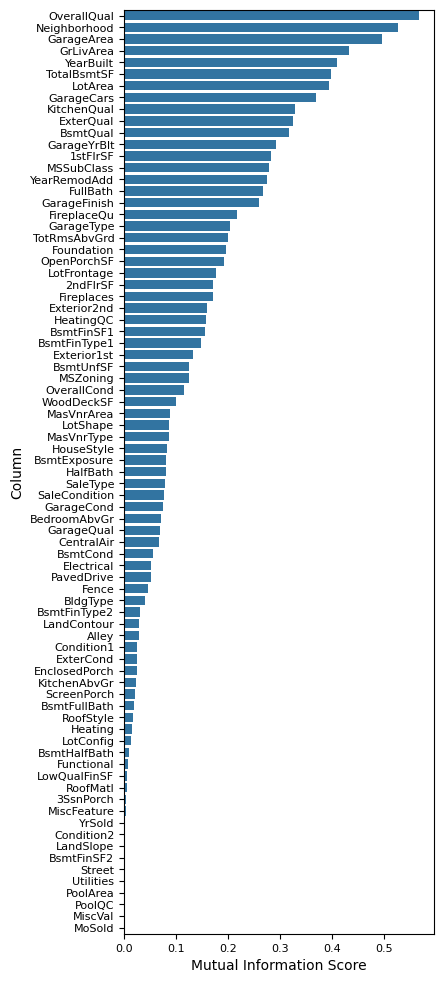

In [15]:
X = train.copy()
y = X.pop('SalePrice')

mi_scores = get_mi_scores(X, y)
plot_mi_scores(mi_scores)

In [16]:
# Delete columns with 0 mutual information so model isn't overfitting.
# Some columns like Poolxxx are mostly 0 or NA because most houses
# don't have pools so this is a reasonable candidate to drop

def drop_uninformative(df, mi_scores):
    print('Dropping the following uninformative columns:')
    print(list(mi_scores[mi_scores == 0.0].index))
    return df.loc[:, mi_scores > 0.0]

X = train.copy()
y = X.pop('SalePrice')
X = drop_uninformative(X, mi_scores)

# removing these seems to help a little bit
print(f'Score after removing uninformative features: {score_model(X, y):.5f} RMSE')

Dropping the following uninformative columns:
['PoolQC', 'MiscVal', 'MoSold']
Score after removing uninformative features: 0.13925 RMSE


## Engineer New Features to Improve Score

In [17]:
def combinations(df):
    '''
    Creates a dataframe of new columns X which
    are meaningful mathematical transformations
    of the columns in df 
    '''
    X = pd.DataFrame()
    X['LivLotRatio']  = df['GrLivArea'] / df['LotArea']
    X['Spaciousness'] = (df['1stFlrSF'] + df['2ndFlrSF']) / df['TotRmsAbvGrd']
    X['TotBath']      = df[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * df[['BsmtHalfBath', 'HalfBath']].sum(axis=1)
    # X['HasBsmt']      = (df['TotalBsmtSF'] > 0).astype(int) # doesn't seem to help much
    # X['Overall']      = df['OverallQual'] * df['OverallCond'] # also doesn't impact result much

    return X


def group_transforms(df):
    '''
    Creates a dataframe of new columns X which
    are group transforms of the columns in df
    '''
    X = pd.DataFrame()

    X['MedNhbdLivArea']  = df.groupby('Neighborhood', observed=False)['GrLivArea'].transform('median')
    X['StdvNhbdLivArea'] = df.groupby('Neighborhood', observed=False)['GrLivArea'].transform('std')
    X['MedNhbdLivDiff']  = df['GrLivArea'] - X['MedNhbdLivArea']

    X['MeanNhbdLotArea'] = df.groupby('Neighborhood', observed=False)['LotArea'].transform('mean')

    return X

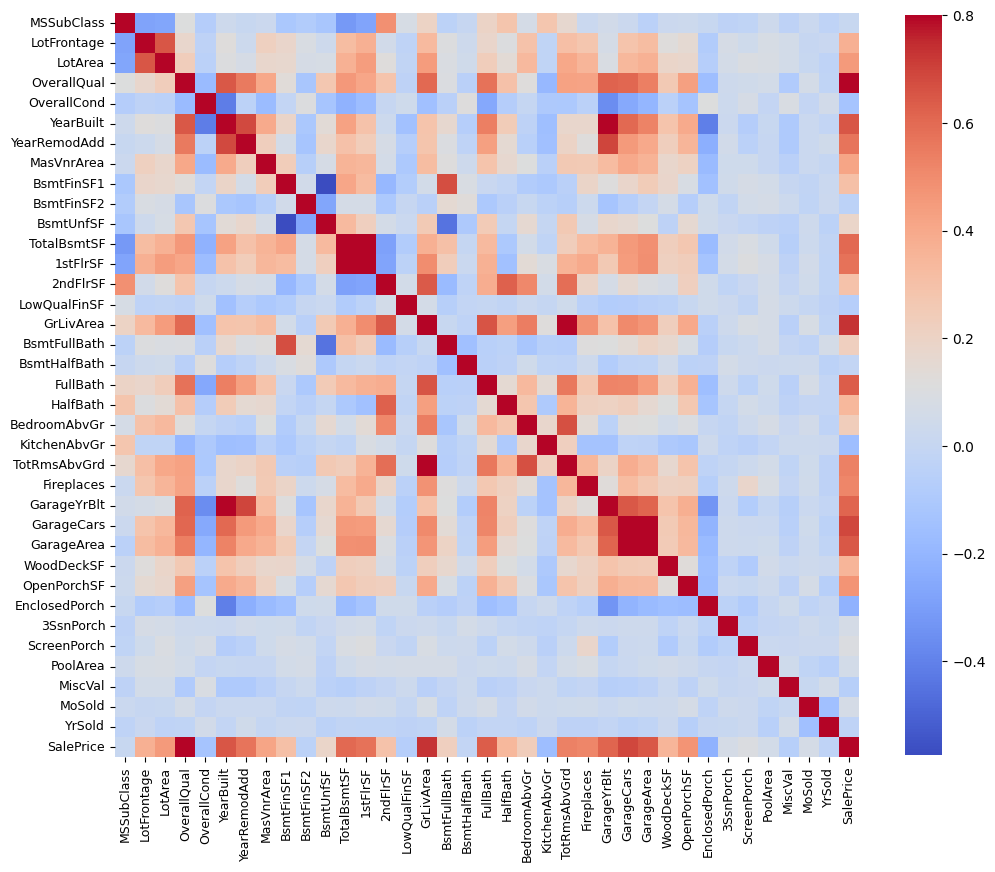

In [80]:
correlation_matrix = train.corr(method='spearman', numeric_only=True) # spearman to account for non-linearity

fig, ax = plt.subplots(figsize=(12,12))
sns.heatmap(correlation_matrix, vmax=0.8, square=True, cbar_kws={'shrink': 0.8}, cmap='coolwarm')

ax.tick_params(axis='both', labelsize=9)
plt.show()

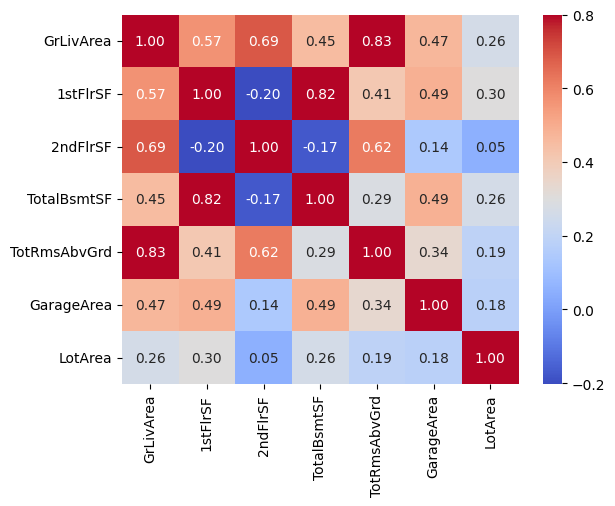

In [84]:
cols = ['GrLivArea', '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF', 
        'TotRmsAbvGrd', 'GarageArea', 'LotArea']

sns.heatmap(train[cols].corr(), vmax=0.8, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [75]:
def apply_pca(X, standardize=True):
    # zscore
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # create principal components
    pca   = PCA()
    X_pca = pca.fit_transform(X)

    component_names = [f'PC{i+1}' for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)

    # create loadings
    loadings = pd.DataFrame(pca.components_.T, columns=component_names, index=X.columns)
    
    return pca, X_pca, loadings


def plot_variance(pca):
    fig, axs = plt.subplots(1, 2)

    n = pca.n_components_
    grid = np.arange(1, n + 1)

    explained_var = pca.explained_variance_ratio_
    axs[0].bar(grid, explained_var)
    axs[0].set_xlabel('Component')
    axs[0].set_title('% Explained Variance')
    axs[0].set_ylim((0.0, 1.0))
    # axs[0].set(xlabel='Component', title='% Explained Variance', ylim=(0.0, 1.0))

    cum_var = np.cumsum(explained_var)
    axs[1].plot(np.r_[0, grid], np.r_[0, cum_var], '-')
    axs[1].set(xlabel='Component', title='% Cumulative Variance', ylim=(0.0, 1.0))

    return axs

In [85]:
# apply PCA to columns that are related and highly correlated
pca_columns = ['GrLivArea', '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF', 'GarageArea']

X = train.copy()
# y = X.pop('SalePrice')
X = X.loc[:, pca_columns]

pca, X_pca, loadings = apply_pca(X)
print(loadings)

                  PC1       PC2       PC3       PC4       PC5
GrLivArea    0.491846  0.438837 -0.275388 -0.225756  0.662348
1stFlrSF     0.530648 -0.299347 -0.279863 -0.548916 -0.499171
2ndFlrSF     0.121339  0.784511 -0.066118  0.231148 -0.558586
TotalBsmtSF  0.509583 -0.319089 -0.213961  0.769861  0.006447
GarageArea   0.449557  0.023174  0.892013 -0.040121  0.008016


array([<Axes: title={'center': '% Explained Variance'}, xlabel='Component'>,
       <Axes: title={'center': '% Cumulative Variance'}, xlabel='Component'>],
      dtype=object)

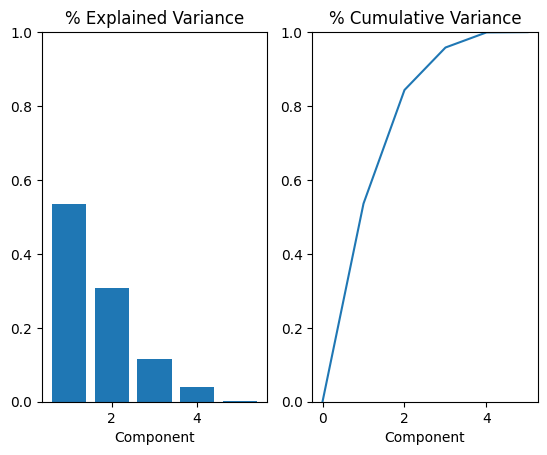

In [86]:
plot_variance(pca)

<Axes: ylabel='Count'>

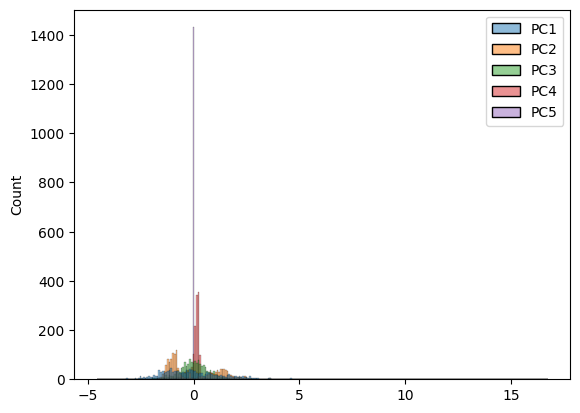

In [87]:
sns.histplot(X_pca)

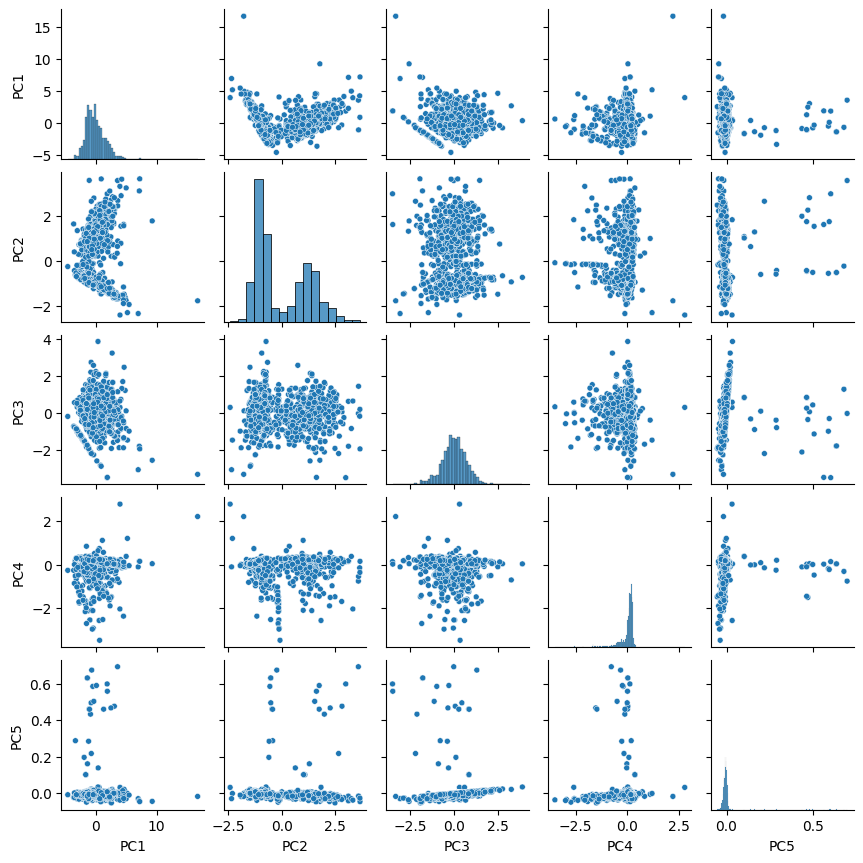

In [88]:
sns.pairplot(X_pca, height=1.75, plot_kws={'marker': 'o', 'size': 20})

In [89]:
xxx = X_pca.join(train[['Neighborhood', 'SaleCondition']])

<Axes: xlabel='PC1', ylabel='PC2'>

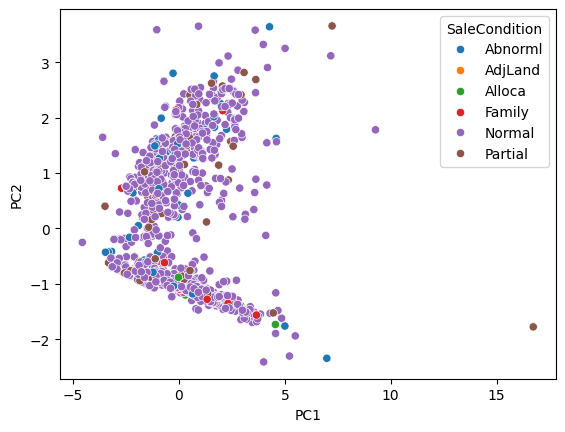

In [92]:
sns.scatterplot(data=xxx, x='PC1', y='PC2', hue='SaleCondition')

In [21]:
# look for outliers
component = 'PC1'

idx = X_pca[component].sort_values(ascending=False).index
train.iloc[idx, :][['SalePrice', 'Neighborhood', 'SaleCondition'] + pca_columns].head()

,SalePrice,Neighborhood,SaleCondition,GrLivArea,TotalBsmtSF,GarageArea,YearBuilt
Id,,,,,,,
1299,160000,Edwards,Partial,5642,6110,1418,2008
524,184750,Edwards,Partial,4676,3138,884,2007
1183,745000,NoRidge,Abnorml,4476,2396,813,1996
692,755000,NoRidge,Normal,4316,2444,832,1994
497,430000,NoRidge,Normal,3228,3200,546,1992


In [22]:
def indicate_outliers(df):
    X_new = pd.DataFrame()
    X_new['Outlier'] = (df['Neighborhood'] == 'Edwards') & (df['SaleCondition'] == 'Partial')
    return X_new

In [23]:
X = train.copy()
y = X.pop('SalePrice')

X = drop_uninformative(X, mi_scores)
X = X.join(combinations(X))
X = X.join(group_transforms(X))
X = X.join(indicate_outliers(X))

print(f'Model score: {score_model(X, y):.5f} RMSE')

Dropping the following uninformative columns:
['PoolQC', 'MiscVal', 'MoSold']
Model score: 0.13395 RMSE


## Investigate Correlations Between Numeric Columns

In [6]:
def plot_scatter(df, x_col, y_col):
    '''
    Create a quick scatter plot between
    two columns in a dataframe
    '''
    data = pd.concat([df[x_col], df[y_col]], axis=1)
    
    data.plot.scatter(x=x_col, y=y_col)
    plt.show()

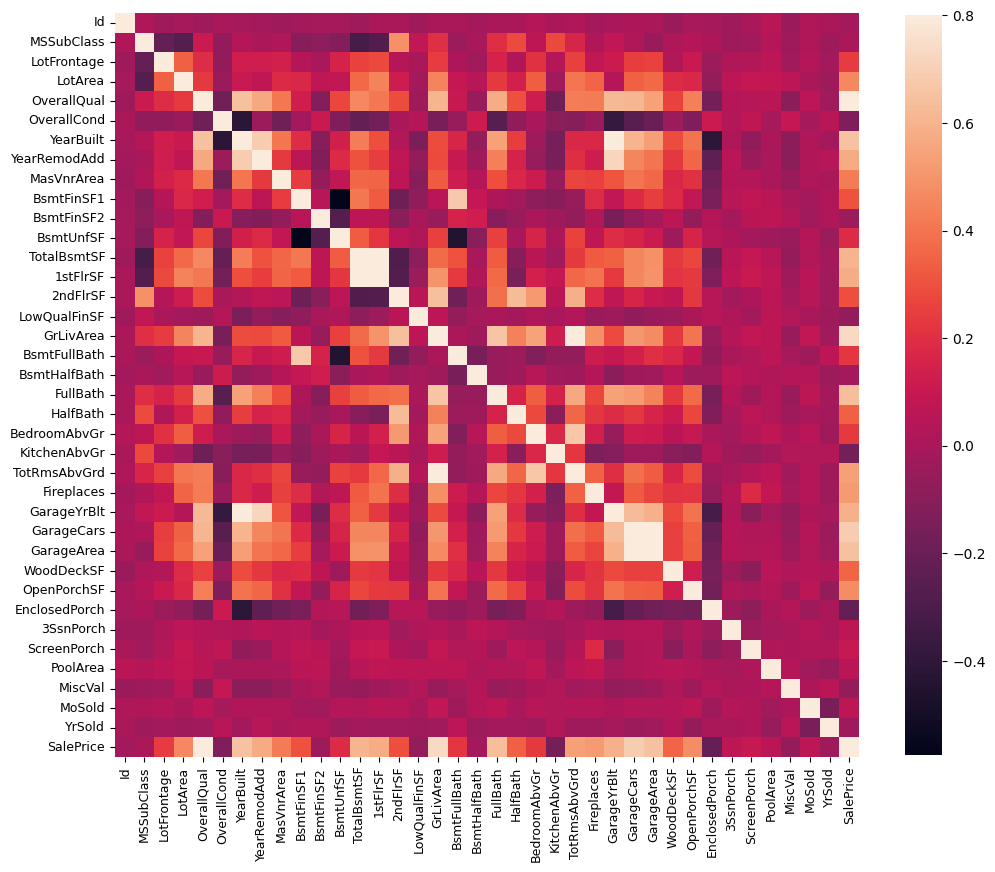

In [81]:
# look at largest correlations between columns
n = 15

mask           = np.tril(np.ones(correlation_matrix.shape), k=-1).astype(bool)
lower_triangle = correlation_matrix.where(mask)

most_correlated_columns = (lower_triangle.unstack().abs().nlargest(n).dropna())

print('Columns with highest Spearman correlation:')
most_correlated_columns

Columns with highest Spearman correlation:


YearBuilt     GarageYrBlt     0.890546
GarageCars    GarageArea      0.853317
TotalBsmtSF   1stFlrSF        0.829292
GrLivArea     TotRmsAbvGrd    0.827874
OverallQual   SalePrice       0.809829
GrLivArea     SalePrice       0.731310
YearRemodAdd  GarageYrBlt     0.722377
GarageCars    SalePrice       0.690711
YearBuilt     YearRemodAdd    0.684388
BsmtFinSF1    BsmtFullBath    0.674175
BedroomAbvGr  TotRmsAbvGrd    0.667822
GrLivArea     FullBath        0.658419
YearBuilt     SalePrice       0.652682
LotFrontage   LotArea         0.649633
GarageArea    SalePrice       0.649379
dtype: float64

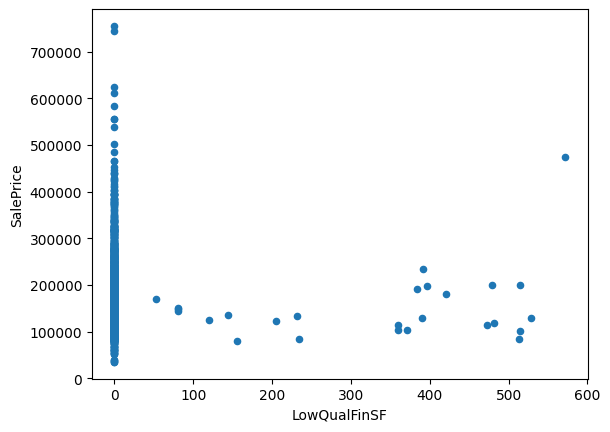

In [ ]:
# house_data['BsmtFinSF'] = house_data['BsmtFinSF1'] + house_data['BsmtFinSF2']

plot_scatter(train, 'LowQualFinSF', 'SalePrice')
# plot_scatter(train, 'KitchenAbvGr', 'SalePrice')
# plot_scatter(train, 'BedroomAbvGr', 'SalePrice')

In [ ]:
# GarageCars and GarageArea essentially represent the same thing
# choose to keep GarageArea so the model has more flexibility to split
train = train.drop(columns=['GarageCars'])

# similarly keep GrLivArea and drop TotRmsAbvGrd and BedroomAbvGr
train = train.drop(columns=['TotRmsAbvGrd', 'BedroomAbvGr'])

# combine bathroom columns into a single bathroom count
train['TotBath'] = train[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * train[['BsmtHalfBath', 'HalfBath']].sum(axis=1)
train = train.drop(columns=['BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath'])

# convert date columns to age to generalize
train['YearBuilt']    = train['YrSold'] - train['YearBuilt']
train['YearRemodAdd'] = train['YrSold'] - train['YearRemodAdd']
train['GarageYrBlt']  = train['YrSold'] - train['GarageYrBlt']

count    1459.000000
mean      256.974297
std        87.975145
min         0.000000
25%       225.416667
50%       263.500000
75%       290.000000
max       924.000000
Name: GarageAreaPerCar, dtype: float64

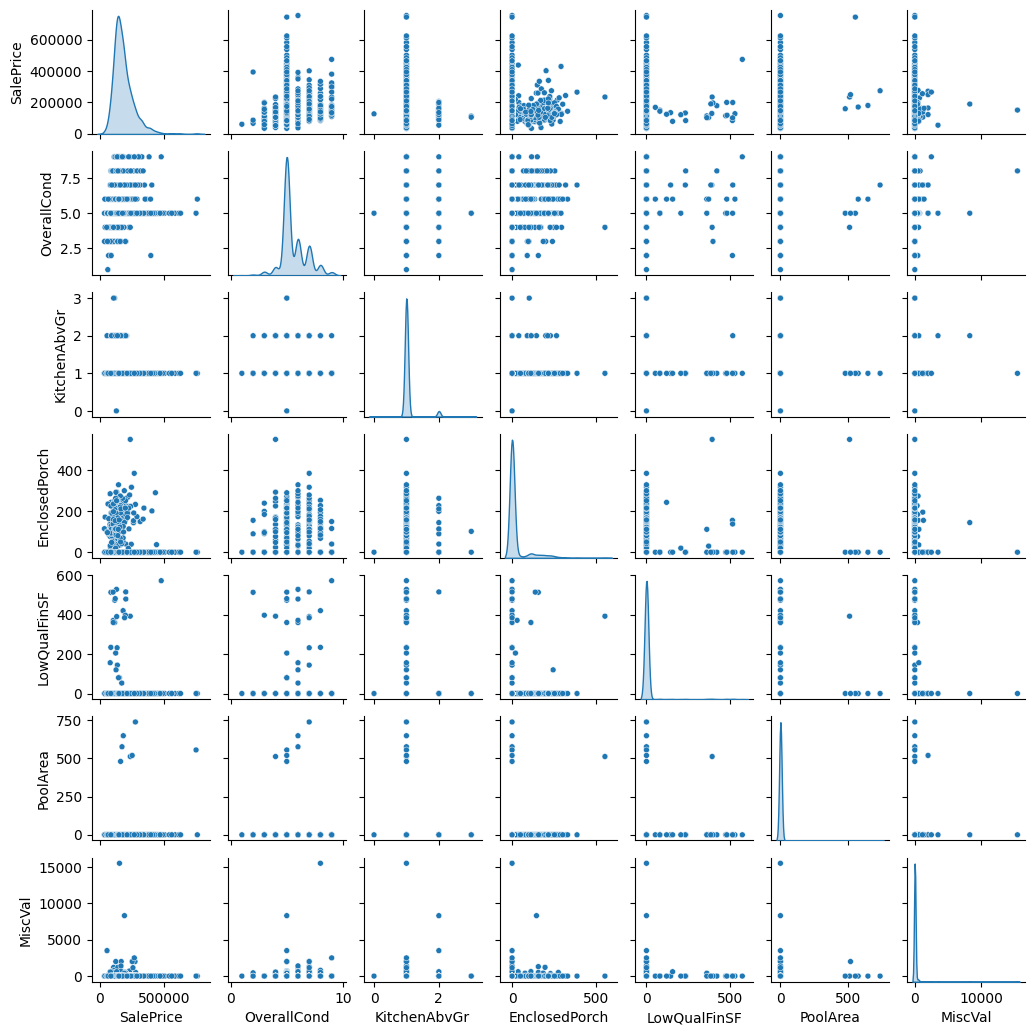

In [52]:
# investigate columns with low correlation to see if we can
# drop them
cols = ['SalePrice', 'OverallCond', 'KitchenAbvGr', 'EnclosedPorch', 'LowQualFinSF', 'PoolArea', 'MiscVal']

sns.pairplot(train[cols], height=1.5, diag_kind='kde', plot_kws={'marker': 'o', 'size': 20})

plt.show()

In [ ]:
# looks like we can drop LowQualFinSF, PoolArea, and MiscVal

## Deal with Outliers
Don't want to train on a few special cases but rather want to focus on the bulk of the data. Check skewness of columns

## Encode Categorical Columns
Check correlation for ordinal variables!!!

## Normalize SalePrice
Do this to avoid skewing the variance that the decision trees are trying to minimize when splitting

# OLD Solution
\
\
\
Spacer

## Start with a simple approach only considering numeric data columns with no missing values
This is the first goal in the Kaggle Intro to Machine Learning course. Further courses will discuss how to address the other data columns so I'll just start with this subset for now. We can first examine all the numeric features available in the dataset to identify which might be good predictors by looking at correlation with SalePrice and feature importances when all data columns are used in a random foret model.

In [2]:
# Load the Kaggle training dataset
path_house_data = './input/train.csv.gz'
house_data      = pd.read_csv(path_house_data, compression='gzip')

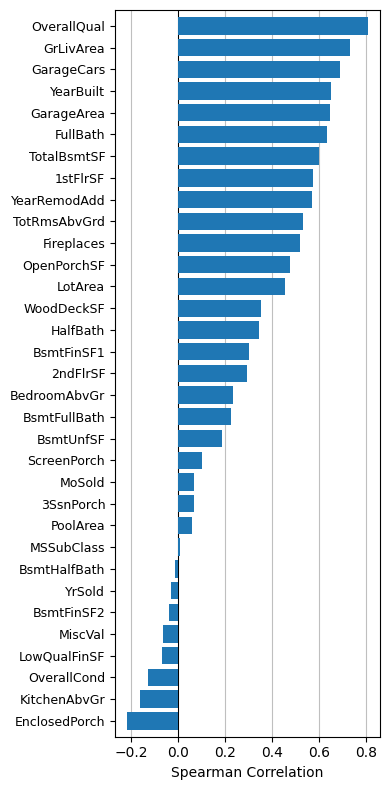

In [3]:
# To get a first estimate of which features might be important we can just
# look at which of the numeric features correlate with sale price.
# Note: use spearman correlation to catch any monotonic relationships
#       that might be nonlinear
correlations = house_data.dropna(axis=1).corr(numeric_only=True, method='spearman')['SalePrice'].sort_values().drop(['SalePrice', 'Id'])
all_columns  = correlations.index.to_list()

fig, ax = plt.subplots(figsize=(4,8))

ax.barh(correlations.index, correlations.values, zorder=10)
ax.axvline(0, color='k', linewidth=0.75, linestyle='-')
ax.tick_params(axis='y', labelsize=9)
ax.set_xlabel('Spearman Correlation')
ax.margins(y=0.01)
ax.grid(axis='x', color='k', alpha=0.25)

fig.tight_layout()
plt.show()

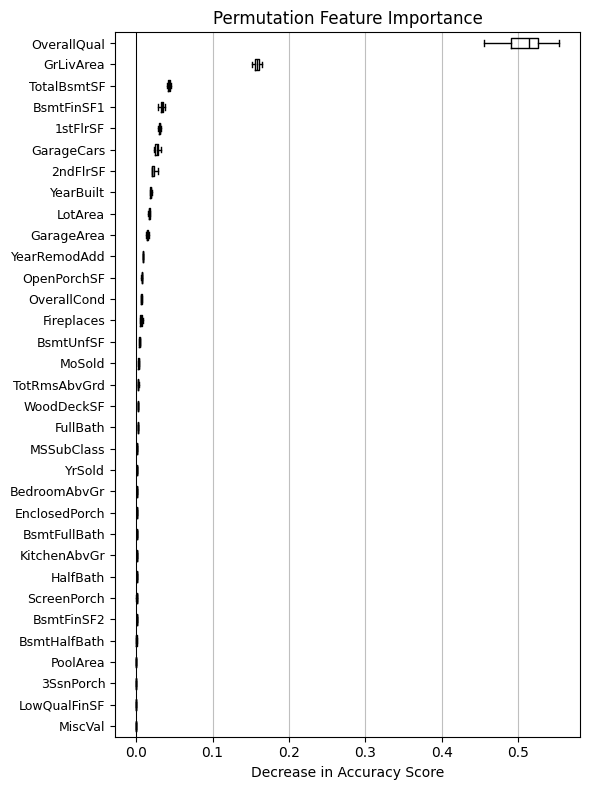

In [4]:
# Alternatively, to identify important features we can train a random
# forest on all these columns and plot the feature importances
# Note: use permutation importance to reduce bias to high-cardinality features

# split training data into training and validation
X = house_data[all_columns]
y = house_data['SalePrice']
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=123)

forest_all = RandomForestRegressor(random_state=123)
forest_all.fit(train_X, train_y)

# calculate permutation importance
importances_all        = permutation_importance(forest_all, train_X, train_y, n_repeats=20, random_state=123, n_jobs=2)
sorted_importances_idx = importances_all.importances_mean.argsort()
importances            = importances_all.importances[sorted_importances_idx].T

fig, ax = plt.subplots(figsize=(6, 8))

labels = [all_columns[i] for i in sorted_importances_idx]
ax.boxplot(importances, vert=False, tick_labels=labels, showfliers=False, medianprops=dict(color='k'))
ax.axvline(0, color='k', linewidth=0.75, linestyle='-')
ax.tick_params(axis='y', labelsize=9)

ax.set_title('Permutation Feature Importance')
ax.set_xlabel('Decrease in Accuracy Score')
ax.grid(axis='x', color='k', alpha=0.25)

plt.tight_layout()
plt.show()

### Feature Selection

In [5]:
all_features = set(all_columns)

In [6]:
def partial_correlation(data_df, x, y, control, method='spearman', verbose=True):
      '''
      Calculate the partial correlation between two columns
      in df after accounting for a control
      '''
      X = sm.add_constant(data_df[control])

      resid_x = sm.OLS(data_df[x], X).fit().resid
      resid_y = sm.OLS(data_df[y], X).fit().resid

      partial_corr = resid_x.corr(resid_y, method=method)

      if verbose:
            print(f'Partial {method.title()} correlation between {x} and {y} after controlling for {control}: {partial_corr:.3f}')

      return partial_corr


def evaluate_model(data_df, features, target='SalePrice', random_seed=123):
      '''
      Trains and evaluates a random forest model using the
      provided data and feature set. Returns the MAE as a
      metric for quick testing and comparison
      '''
      X = data_df[features]
      y = data_df[target]
      train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=random_seed)

      model = RandomForestRegressor(random_state=random_seed)
      model.fit(train_X, train_y)
      
      return mean_absolute_error(val_y, model.predict(val_X))


def run_cross_val(data_df, features, target='SalePrice', cv=5, scoring='neg_mean_absolute_error', random_seed=123):
      '''
      Wraps a call to cross_val_score to avoid repeating
      same long call
      '''
      return cross_val_score(RandomForestRegressor(random_state=random_seed), data_df[features], data_df[target], cv=cv, scoring=scoring)

In [7]:
# GrLivArea is just the sum of the 3 other internal square footage columns
# and is correlated more strongly with SalePrice than the other 3. Can we
# drop the 3 other columns to simplify the model? Info on the number of floors 
# is also included in MSSubClass so should keep that in mind

print('Check partial correlations')
partial_correlation(house_data, '1stFlrSF', 'SalePrice', control='GrLivArea')
partial_correlation(house_data, '2ndFlrSF', 'SalePrice', control='GrLivArea')
partial_correlation(house_data, 'LowQualFinSF', 'SalePrice', control='GrLivArea')

print('\nCheck model performance')

test_features = list(all_features) # all column baseline
scores = run_cross_val(house_data, test_features)
print(f'MAE with current set of features: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(all_features - {'GrLivArea'}) # only use individual columns instead of combined column
scores = run_cross_val(house_data, test_features)
print(f'MAE without GrLivArea: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')


test_features = list(all_features - {'1stFlrSF', '2ndFlrSF', 'LowQualFinSF'}) # use only combined column
scores = run_cross_val(house_data, test_features)
print(f'MAE with only GrLivArea: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

# choose to keep all the features
current_features = all_features

Check partial correlations
Partial Spearman correlation between 1stFlrSF and SalePrice after controlling for GrLivArea: 0.388
Partial Spearman correlation between 2ndFlrSF and SalePrice after controlling for GrLivArea: -0.365
Partial Spearman correlation between LowQualFinSF and SalePrice after controlling for GrLivArea: -0.011

Check model performance
MAE with current set of features: $18,057 ± $1,032
MAE without GrLivArea: $18,411 ± $890
MAE with only GrLivArea: $18,062 ± $1,113


In [ ]:
# Similar argument for basement SF. TotalBsmtSF is the sum of BsmtFinSF1,
# BsmtFinSF2, and BsmtUnfSF however we should differentiate between finished
# and unfinished basement. Try combining to produce a single BsmtFinSF column

house_data['BsmtFinSF'] = house_data['BsmtFinSF1'] + house_data['BsmtFinSF2']

print('Check model performance')

test_features = list(current_features) # all column baseline
scores = run_cross_val(house_data, test_features)
print(f'MAE with current set of features: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features - {'TotalBsmtSF'}) # remove sum row
scores = run_cross_val(house_data, test_features)
print(f'MAE without TotalBsmtSF: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features - {'BsmtFinSF1', 'BsmtFinSF2', 'TotalBsmtSF'}) + ['BsmtFinSF'] # combine finished SF 
scores = run_cross_val(house_data, test_features)
print(f'MAE with combined BsmtFinSF: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

# no improvement here so we keep all the features
current_features = all_features

Check model performance
MAE with current set of features: $18,057 ± $1,032
MAE without TotalBsmtSF: $18,064 ± $1,090
MAE with combined BsmtFinSF: $18,142 ± $1,245


In [9]:
# GarageCars and GarageArea are highly correlated which makes intuitive sense
# but they both represent a very similar thing. Maybe we can drop one

garage_corr = house_data['GarageCars'].corr(house_data['GarageArea'], method='spearman')
print(f'Spearman correlation between GarageCars and GarageArea: {garage_corr:.3f}')

print('\nCheck model performance')

test_features = list(current_features) # all column baseline
scores = run_cross_val(house_data, test_features)
print(f'MAE with current set of features: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features - {'GarageCars'})
scores = run_cross_val(house_data, test_features)
print(f'MAE without GarageCars: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features - {'GarageArea'})
scores = run_cross_val(house_data, test_features)
print(f'MAE without GarageArea: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

# no improvement here so we keep all the features
current_features = all_features

Spearman correlation between GarageCars and GarageArea: 0.853

Check model performance
MAE with current set of features: $18,057 ± $1,032
MAE without GarageCars: $18,279 ± $1,207
MAE without GarageArea: $17,946 ± $1,089


In [10]:
# We can combine all the bathroom columns into one combined total bathrooms number
# to remove seemingly redundant columns
house_data['TotBath'] = house_data[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * house_data[['BsmtHalfBath', 'HalfBath']].sum(axis=1)

print('Check model performance')

test_features = list(current_features) # all column baseline
scores = run_cross_val(house_data, test_features)
print(f'MAE with current set of features: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features) + ['TotBath']
scores = run_cross_val(house_data, test_features)
print(f'MAE with added TotBath: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features - {'BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath'}) + ['TotBath']
scores = run_cross_val(house_data, test_features)
print(f'MAE with bathrooms replaced with TotBath: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

# no improvement here so we keep all the features
current_features = all_features

Check model performance
MAE with current set of features: $18,057 ± $1,032
MAE with added TotBath: $17,998 ± $1,156
MAE with bathrooms replaced with TotBath: $17,943 ± $1,151


In [11]:
# Lots of different types of porches, we can try to combine them to
# get a total porch area to reduce redundancy
house_data['TotPorchSF'] = house_data[['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']].sum(axis=1)

print('Check model performance')

test_features = list(current_features) # all column baseline
scores = run_cross_val(house_data, test_features)
print(f'MAE with current set of features: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features) + ['TotPorchSF']
scores = run_cross_val(house_data, test_features)
print(f'MAE with added TotPorchSF: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features - {'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch'}) + ['TotPorchSF']
scores = run_cross_val(house_data, test_features)
print(f'MAE with porch columns replaced with TotPorchSF: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

# no meaningful difference so keep all features
current_features = all_features

Check model performance
MAE with current set of features: $18,057 ± $1,032
MAE with added TotPorchSF: $18,098 ± $1,108
MAE with porch columns replaced with TotPorchSF: $17,970 ± $1,103


I didn't find any significant performance improvement by selecting features manually. Can still try with SequentialFeatureSelector or RFECV (Recursive Feature Elimination with CV) but for this dataset size and cv error it's probably not worth it.

### Model Training
With features chosen we can tune the hyperparameters of the final model. Key parameters to look at include:
- **n_estimators** -> Number of trees. More = more stable, diminishing returns past ~300
- **max_depth** -> Max depth per tree. None = fully grown (may overfit), lower = more regularization
- **min_samples_leaf** -> Min samples at a leaf node. Higher = simpler trees, less overfit
- **max_features** -> Features considered at each split. Lower = more diverse trees

In [13]:
param_dist = {'n_estimators'     : [100, 200, 300, 500],
              'max_depth'        : [None, 10, 20, 30],
              'min_samples_leaf' : [1, 2, 4, 8],
              'max_features'     : ['sqrt', 'log2', 0.5, 0.8],
              }

search = RandomizedSearchCV(RandomForestRegressor(random_state=123),
                            param_distributions = param_dist,
                            n_iter              = 40,
                            cv                  = 5,
                            scoring             = 'neg_mean_absolute_error',
                            random_state        = 123,
                            n_jobs              = -1,
                            )

search.fit(house_data[list(current_features)], house_data['SalePrice'])

print(f'Best MAE:    ${-search.best_score_:,.0f}')
print(f'Best params: {search.best_params_}')

Best MAE:    $17,129
Best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}


### Train Final Model and Generate Predictions
I didn't actually use any of the additional feature columns I created above so I can just read the test data and generate predictions directly

In [15]:
final_features = list(current_features)

X = house_data[final_features]
y = house_data['SalePrice']

final_forest_model = RandomForestRegressor(random_state=123, **search.best_params_)
final_forest_model.fit(X, y)

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
path_test_data = './input/test.csv.gz'
test_data      = pd.read_csv(path_test_data, compression='gzip')

test_X      = test_data[final_features]
predictions = final_forest_model.predict(test_X)

# save final predictions
output = pd.DataFrame({'Id'        : test_data.Id,
                       'SalePrice' : predictions,
                       })
output.to_csv('./output/submission.csv', index=False)